# Kunskapskontroll 1 

## 1. Inledning och kontext

Detta dataset representerar en simulering och statististisk sammaställning av de 48 landslag som förväntas delta i **FIFA World Cup 2026**

**Om datan:**
- **Källor:** Det används två dataset från Kaggle: 
    - FIFA World Cup Team Dataset, här har jag sparat två filer: fifa_history (som är historisk statistik från tidigare vm ) samt fifa_2026 (som är statisitk simulering av de 48 lagen inför vm 2026)
    - Football Transfer Market Dataset, här har jag sparat två filer: players (spelare från hela världen ) samt transfermarkt ( övergångar över alla ligor)
- **Population:** Varje rad representerar ett specifikt landslag. 
- **Variabler:** Datasetet innehåller 24 kolumner med allt från historiska meriter (tidigare titlar) till nuvarande form (mål och vinster de senaste 4 åren)
- **Syfte:** Att undersöka faktorer som påverkar ett lags förväntade framgång inför det utökade VM-formatet
- **Begränsningar:* Datasetet för historik sträcker sig från 2002 till 2022, vilket innebär att äldre historiska prestationer (som Frankrikes guld 1998) inte inkluderas i analysen.
Eftersom jag slår ihop två dataset där vi har historisk data och framtida data. Detta gör att viss data kommer inte att finnas till exempel på winner för 2026. jag väljer att radera dessa tomma rader automatiskt. Detta för att inte medvetet blanda ihop faktiska resultat med framtidsprogrnoser utifrån missvisande sätt.  



In [3]:
# importera de olika paketen. Vi använder oss av matplotlib och seabord för att skapa visuella diagram
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.expand_frame_repr", False)

# 2. Inmatning och verifiering

### hämta in dataseten som jag ska arbeta med och se hur stora de är

In [4]:
# Ladda in alla dataseten som vi arbetar med
df_history = pd.read_csv("data/fifa_history.csv")
df_2026 = pd.read_csv("data/fifa_2026.csv")
df_players = pd.read_csv(f"data/players.csv")
df_market = pd.read_csv(f"data/transfermarkt.csv")

# Inspektera historisk data för tidigare vm
print("history table")
print(f"Historik (Train): {df_history.shape[0]} rader, {df_history.shape[1]} kolumner")
display(df_history.head(3))

print(" ")

# Inspektera framtida data
print("wc 2026 table")
print(f"VM 2026 (Test): {df_2026.shape[0]} rader, {df_2026.shape[1]} kolumner")
display(df_2026.head(3))

print(" ")

# Inspektera spelardata
print("players table")
print(f"Spelardata: {df_players.shape[0]} rader, {df_players.shape[1]} kolumner")
display(df_players.head(3))

print(" ")

# Inspektera marknadsvärdesdata
print("transfermarkt table")
print(f"Marknadsvärde: {df_market.shape[0]} rader, {df_market.shape[1]} kolumner")
display(df_market.head(3))

history table
Historik (Train): 192 rader, 24 kolumner


,version,team,continent,is_host,goals_scored_last_4y,goals_received_last_4y,wins_last_4y,losses_last_4y,draws_last_4y,world_cup_titles_before,squad_total_market_value_eur,fifa_rank_pre_tournament,fifa_points_pre_tournament,squad_avg_age,world_cup_participations_before,groups_passed_before,round16_before,quarterfinals_before,semifinals_before,finals_before,winner,finalist,semi_finalist,quarter_finalist
0,2006,Angola,Africa,0,61,49,19,13,14,0,52700000.0,57,581.0,29.2,0,0,0,0,0,0,0,0,0,0
1,2006,Argentina,South America,0,97,55,31,10,10,2,777200000.0,9,746.0,27.8,13,10,5,6,4,4,0,0,0,1
2,2006,Australia,Oceania,0,101,34,23,8,5,0,48030000.0,42,612.0,27.1,1,0,0,0,0,0,0,0,0,0


 
wc 2026 table
VM 2026 (Test): 48 rader, 24 kolumner


,version,team,continent,is_host,goals_scored_last_4y,goals_received_last_4y,wins_last_4y,losses_last_4y,draws_last_4y,world_cup_titles_before,squad_total_market_value_eur,fifa_rank_pre_tournament,fifa_points_pre_tournament,squad_avg_age,world_cup_participations_before,groups_passed_before,round16_before,quarterfinals_before,semifinals_before,finals_before,winner,finalist,semi_finalist,quarter_finalist
0,2026,France,Europe,0,85,32,25,6,7,2,1290000000,1,1877.32,26.7,16,10,8,9,7,4,NaN,NaN,NaN,NaN
1,2026,Spain,Europe,0,104,32,29,2,8,1,1150000000,2,1876.40,27.2,16,11,9,6,2,1,NaN,NaN,NaN,NaN
2,2026,Argentina,South America,0,80,14,30,4,3,3,575000000,3,1874.81,27.9,18,15,10,10,6,6,NaN,NaN,NaN,NaN


 
players table
Spelardata: 1975 rader, 8 kolumner


,PlayerName,Post,Age,MarketValue,Nationality,Left,Current_team,Fee
0,Kylian Mbappé,Centre-Forward,25,180.00m,France,Paris Saint-Germain,Real Madrid,free transfer
1,Victor Osimhen,Centre-Forward,25,100.00m,Nigeria,SSC Napoli,Galatasaray,loan transfer
2,Julián Alvarez,Centre-Forward,24,90.00m,Argentina,Manchester City,Atlético de Madrid,75.00m


 
transfermarkt table
Marknadsvärde: 1475 rader, 10 kolumner


,Name,Age,Position,Player Nationality,Market Value,Left,LeagueLefted,Joined,LeagueJoined,Fee
0,Kylian Mbappé,25,Centre-Forward,France,180.0,Paris SG,Ligue 1,Real Madrid,LaLiga,NaN
1,Victor Osimhen,25,Centre-Forward,Nigeria,100.0,Napoli,Serie A,Galatasaray,Süper Lig,NaN
2,Julián Alvarez,24,Centre-Forward,Argentina,90.0,Man City,Premier League,Atlético Madrid,LaLiga,75.0


### Sammanslagningen
här slår vi ihop historiska och framtida dataseten till en. 

In [5]:
# 1. (Valfritt men smart) Ge dem en "etikett" så vi vet vad som är vad sen
df_history["status"] = "Historik"
df_2026["status"] = "2026"
df_market[""] = "market"
df_players["afla"] = "player"
# 2. Slå ihop dem 
# ignore_index=True gör att vi får en ny snygg numrering från 0 till slutet
df = pd.concat([df_history, df_2026], ignore_index=True)

dff = pd.concat([df_market, df_players], ignore_index=True)
display(dff)

# 3. Kontrollera resultatet
print(f"Nu har vi slagit ihpa de två dataseten och då får vi totalt antal rader: {df.shape[0]}") 

print (" ")
print(" här ser vi slutet av datasetet där data från prediktion är.")
display(df.tail())  
df.isnull().sum() # kollar antalet icke siffer värden 

,Name,Age,Position,Player Nationality,Market Value,Left,LeagueLefted,Joined,LeagueJoined,Fee,,PlayerName,Post,MarketValue,Nationality,Current_team,afla
0,Kylian Mbappé,25,Centre-Forward,France,180.0,Paris SG,Ligue 1,Real Madrid,LaLiga,NaN,market,NaN,NaN,NaN,NaN,NaN,NaN
1,Victor Osimhen,25,Centre-Forward,Nigeria,100.0,Napoli,Serie A,Galatasaray,Süper Lig,NaN,market,NaN,NaN,NaN,NaN,NaN,NaN
2,Julián Alvarez,24,Centre-Forward,Argentina,90.0,Man City,Premier League,Atlético Madrid,LaLiga,75.0,market,NaN,NaN,NaN,NaN,NaN,NaN
3,Khvicha Kvaratskhelia,23,Left Winger,Georgia,85.0,Napoli,Serie A,Paris SG,Ligue 1,70.0,market,NaN,NaN,NaN,NaN,NaN,NaN
4,Xavi Simons,21,Attacking Midfield,Netherlands,80.0,Paris SG,Ligue 1,RB Leipzig,Bundesliga,50.0,market,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3445,NaN,26,NaN,NaN,NaN,Middlesbrough FC,NaN,NaN,NaN,loan transfer,NaN,Lukas Engel,Left-Back,2.20m,Denmark,FC Cincinnati,player
3446,NaN,24,NaN,NaN,NaN,SK Slavia Prague,NaN,NaN,NaN,loan transfer,NaN,Conrad Wallem,Right Midfield,2.20m,Norway,St. Louis CITY SC,player
3447,NaN,21,NaN,NaN,NaN,Deportivo Cali,NaN,NaN,NaN,0,NaN,Juan Córdoba,Right Winger,1.20m,Colombia,GNK Dinamo Zagreb,player
3448,NaN,28,NaN,NaN,NaN,Adana Demirspor,NaN,NaN,NaN,free transfer,NaN,Dorukhan Toköz,Central Midfield,2.10m,Türkiye,Eyüpspor,player


Nu har vi slagit ihpa de två dataseten och då får vi totalt antal rader: 240
 
 här ser vi slutet av datasetet där data från prediktion är.


,version,team,continent,is_host,goals_scored_last_4y,goals_received_last_4y,wins_last_4y,losses_last_4y,draws_last_4y,world_cup_titles_before,squad_total_market_value_eur,fifa_rank_pre_tournament,fifa_points_pre_tournament,squad_avg_age,world_cup_participations_before,groups_passed_before,round16_before,quarterfinals_before,semifinals_before,finals_before,winner,finalist,semi_finalist,quarter_finalist,status
235,2026,Cape Verde,Africa,0,46,39,16,10,12,0,31830000.0,69,1366.13,29.2,0,0,0,0,0,0,NaN,NaN,NaN,NaN,2026
236,2026,Ghana,Africa,0,46,42,12,13,9,0,164900000.0,74,1346.31,25.1,4,2,2,1,0,0,NaN,NaN,NaN,NaN,2026
237,2026,Cura?o,North America,0,55,39,12,10,10,0,25380000.0,82,1294.65,26.5,0,0,0,0,0,0,NaN,NaN,NaN,NaN,2026
238,2026,Haiti,North America,0,71,37,16,8,8,0,38750000.0,83,1291.71,27.6,1,0,0,0,0,0,NaN,NaN,NaN,NaN,2026
239,2026,New Zealand,Oceania,0,63,32,13,12,6,0,16430000.0,85,1281.57,27.8,2,0,0,0,0,0,NaN,NaN,NaN,NaN,2026


version                             0
team                                0
continent                           0
is_host                             0
goals_scored_last_4y                0
goals_received_last_4y              0
wins_last_4y                        0
losses_last_4y                      0
draws_last_4y                       0
world_cup_titles_before             0
squad_total_market_value_eur       32
fifa_rank_pre_tournament            0
fifa_points_pre_tournament          0
squad_avg_age                       0
world_cup_participations_before     0
groups_passed_before                0
round16_before                      0
quarterfinals_before                0
semifinals_before                   0
finals_before                       0
winner                             48
finalist                           48
semi_finalist                      48
quarter_finalist                   48
status                              0
dtype: int64

### data integration : 
aggregering av spelarvärden och skapa en enhetlig dataset

In [6]:
# 1. En funktion som fattar skillnaden på 'm' och 'k'
def clean_market_value(val):
    if pd.isna(val) or val == "":
        return 0.0

    val = str(val).lower().replace("€", "").strip()

    if "m" in val:
        # '180.00m' -> 180.0
        return float(val.replace("m", ""))
    elif "k" in val:
        # '800k' -> 0.8 (vi gör om tusen till miljoner för att matcha)
        return float(val.replace("k", "")) / 1000

    try:
        return float(val)
    except:
        return 0.0


# 2. Kör funktionen på MarketValue
df_players["MarketValue"] = df_players["MarketValue"].apply(clean_market_value)

# 3. Nu kan du gruppera precis som förut!
df_economy = (
    df_players.groupby("Nationality")
    .agg(
        {
            "MarketValue": "sum",
            "Age": "mean",
            "PlayerName": "count",
        }
    )
    .reset_index()
)

# 4. sparar en kopia som vi döper med
df_economy.columns = ["team_name", "total_market_value", "avg_age", "squad_size"]
df_before_merge = df.copy()

# 5. Merge
df_final = pd.merge(df, df_economy, left_on="team", right_on="team_name", how="left")

# 6. Fyll 0 för de som saknas
df_final["total_market_value"] = df_final["total_market_value"].fillna(0)

print("Tvätten klar! Nu är alla 'k' och 'm' omgjorda till siffror (i miljoner).")

Tvätten klar! Nu är alla 'k' och 'm' omgjorda till siffror (i miljoner).


## 3. Datatvätt 
ta bort data(NaN) som vi inte behöver och som vi inte vill hantera för att inte få felaktiga resultat

Efter sammanslagningen ser vi att kolumnerna winner, finalist, semi_finalist och quarter_finalist har många saknade värden.

Motivering: Dessa NaN beror inte på felaktig datainsamling, utan på att 2026-turneringen ännu inte har spelats. För att kunna använda dessa kolumner i numeriska analyser väljer jag att imputera (fylla) dessa värden med 0. Detta representerar att lagen i projektionen för 2026 än så länge har noll vinster eller finalplatser i det kommande mästerskapet.

In [7]:
# Lista på de kolumner som rör slutplaceringar
cols_to_fix = ["winner", "finalist", "semi_finalist", "quarter_finalist"]

# Fyll alla NaN i dessa kolumner med 0
df[cols_to_fix] = df[cols_to_fix].fillna(0)

# Verifiera att de saknade värdena är borta i just dessa kolumner
print("Antal saknade värden efter tvätt:")
print(df[cols_to_fix].isnull().sum())

Antal saknade värden efter tvätt:
winner              0
finalist            0
semi_finalist       0
quarter_finalist    0
dtype: int64


## datatyper

Här vill vi verifiera så att de olika kolumnerna har rätt datatyper. Detta är för att vi ska kunna arbeta med dem på rätt sätt. 
Här listar jag alla kolumneran och här ser vi också att det inte finns några objekt. det hade medfört problem när vi ska räkna ut medelvärden eller skapa grafer

In [8]:
# Kolla vilka typer kolumnerna har
print(df.dtypes)

version                              int64
team                                   str
continent                              str
is_host                              int64
goals_scored_last_4y                 int64
goals_received_last_4y               int64
wins_last_4y                         int64
losses_last_4y                       int64
draws_last_4y                        int64
world_cup_titles_before              int64
squad_total_market_value_eur       float64
fifa_rank_pre_tournament             int64
fifa_points_pre_tournament         float64
squad_avg_age                      float64
world_cup_participations_before      int64
groups_passed_before                 int64
round16_before                       int64
quarterfinals_before                 int64
semifinals_before                    int64
finals_before                        int64
winner                             float64
finalist                           float64
semi_finalist                      float64
quarter_fin

### Gör om resultat-kolumnerna till heltal
verifierar så att det stämmer undertill med

In [9]:
cols_to_int = ["winner", "finalist", "semi_finalist", "quarter_finalist"]
df[cols_to_int] = df[cols_to_int].astype(int)

# Kontrollera att det blev rätt
print(df[cols_to_int].dtypes)

winner              int64
finalist            int64
semi_finalist       int64
quarter_finalist    int64
dtype: object


### Kolla så att samma kontinent inte har flera olika namn
Så det ska vara Unika kontinenter i datasetet

In [10]:
print("Unika kontinenter i datasetet:")
print(df["continent"].unique())

Unika kontinenter i datasetet:
<StringArray>
['Africa', 'South America', 'Oceania', 'North America', 'Europe', 'Asia']
Length: 6, dtype: str


### Tar bort eventuella osynliga mellanslag i början eller slutet av namnen


In [11]:
df["team"] = df["team"].str.strip()

In [12]:
# Skapa en kolumn för "Målskillnad" de senaste 4 åren
df["goal_diff_4y"] = df["goals_scored_last_4y"] - df["goals_received_last_4y"]

# Skapa en kolumn för "Win Rate" (vinstprocent)
df["win_rate"] = np.where(
    (df["wins_last_4y"] + df["losses_last_4y"] + df["draws_last_4y"]) > 0,
    df["wins_last_4y"]
    / (df["wins_last_4y"] + df["losses_last_4y"] + df["draws_last_4y"]),
    0,
)

In [13]:
# Jämför genomsnittligt marknadsvärde per kontinent
continent_analysis = (
    df.groupby("continent")["squad_total_market_value_eur"]
    .mean()
    .sort_values(ascending=False)
)
print(continent_analysis)

continent
Europe           5.511698e+08
South America    4.384120e+08
Africa           1.751153e+08
North America    9.747250e+07
Asia             7.748852e+07
Oceania          3.202500e+07
Name: squad_total_market_value_eur, dtype: float64


In [14]:
# Kolla korrelationen mellan marknadsvärde och vinster
correlation = df["squad_total_market_value_eur"].corr(df["wins_last_4y"])
print(f"Sambandet mellan värde och vinster är: {correlation:.2f}")

Sambandet mellan värde och vinster är: 0.29


In [15]:
# Vi sorterar först efter kontinent och sen efter antal finaler (fallande)
top_finalists = df.sort_values(["continent", "finals_before"], ascending=[True, False])

# Nu behåller vi bara den första raden för varje kontinent (alltså den med flest finaler)
top_finalists_per_continent = top_finalists.drop_duplicates(subset="continent")

# Vi väljer ut de kolumner som är intressanta att visa
result = top_finalists_per_continent[["continent", "team", "finals_before"]]

print("Lag med flest finalplatser per kontinent:")
display(result)

Lag med flest finalplatser per kontinent:


,continent,team,finals_before
0,Africa,Angola,0
12,Asia,Iran,0
43,Europe,Germany,8
4,North America,Costa Rica,0
2,Oceania,Australia,0
3,South America,Brazil,6


Analys av finalplatser:
"Resultatet bekräftar en historisk dominans från Europa och Sydamerika. Det är intressant att notera att Tyskland (8) har fler finalplatser än Brasilien (6), trots att Brasilien har fler titlar totalt. För övriga kontinenter ser vi att ingen nation ännu nått en final, vilket belyser den stora utmaningen för dessa lag inför det utökade mästerskapet 2026."

In [16]:
# Visa både finaler och titlar för topplagen
result_extended = top_finalists_per_continent[
    ["continent", "team", "finals_before", "world_cup_titles_before"]
]
display(result_extended)

,continent,team,finals_before,world_cup_titles_before
0,Africa,Angola,0,0
12,Asia,Iran,0,0
43,Europe,Germany,8,4
4,North America,Costa Rica,0,0
2,Oceania,Australia,0,0
3,South America,Brazil,6,5


In [17]:
# Summera alla finaler per kontinent
continent_total_finals = (
    df.groupby("continent")["finals_before"].sum().sort_values(ascending=False)
)

print("Totala antalet finalplatser per kontinent (historiskt):")
print(continent_total_finals)

Totala antalet finalplatser per kontinent (historiskt):
continent
Europe           100
South America     68
Asia               0
Africa             0
North America      0
Oceania            0
Name: finals_before, dtype: int64


In [18]:
# Hitta länder som inte fick någon matchning i spelar-datan
missing_data = df_final[df_final["total_market_value"].isnull()]["team"].unique()

if len(missing_data) > 0:
    print(f"Varning! Dessa länder saknar marknadsvärde: {missing_data}")
else:
    print("Snyggt! Alla länder matchades perfekt.")

Snyggt! Alla länder matchades perfekt.


In [19]:
# Nu fungerar nlargest eftersom det är siffror!
print("Topp 5 dyraste trupperna:")
display(df_final.nlargest(5, "total_market_value")[["team", "total_market_value"]])

print("\n5 billigaste trupperna:")
display(df_final.nsmallest(5, "total_market_value")[["team", "total_market_value"]])

Topp 5 dyraste trupperna:


,team,total_market_value
9,France,1452.4
42,France,1452.4
75,France,1452.4
104,France,1452.4
141,France,1452.4



5 billigaste trupperna:


,team,total_market_value
14,Ivory Coast,0.0
22,Serbia and Montenegro,0.0
23,South Korea,0.0
58,South Korea,0.0
85,Qatar,0.0


In [20]:
print(f"Rader innan merge: {df_before_merge.shape[0]}")
print(f"Rader efter merge: {df_final.shape[0]}")

Rader innan merge: 240
Rader efter merge: 240


In [21]:
# Använd df_final här!
winner_value_check = df_final.groupby("world_cup_titles_before")[
    "total_market_value"
].mean()
print("Snittvärde baserat på antal VM-titlar:")
print(winner_value_check)

Snittvärde baserat på antal VM-titlar:
world_cup_titles_before
0     173.489950
1    1240.900000
2     700.900000
3     591.233333
4     675.040000
5    1359.200000
Name: total_market_value, dtype: float64


## Diagram

vi börjar med att sortera ut de 10 dyraste lagen utifrån marknads värdet och skriver ut det så att vi kan verifiera så att datan ser ok ut

In [22]:
top_10_expensive = df_final[df_final["status"] == "2026"].nlargest(
    10, "total_market_value"
)


df_clean_top_10 = top_10_expensive.reset_index(drop=True)
print(df_clean_top_10)
# plt.figure(figsize=(12, 6))
# sns.barplot(data=top_10_expensive, x="total_market_value", y="team", palette="viridis")

# plt.title("Top 10 dyraste landslagen inför VM 2026", fontsize=15)
# plt.xlabel("Totalt marknadsvärde (Miljoner €)", fontsize=12)
# plt.ylabel("Landslag", fontsize=12)
# plt.grid(axis="x", linestyle="--", alpha=0.7)

# plt.tight_layout()
# plt.savefig("top_10_market_value.png")

   version         team      continent  is_host  goals_scored_last_4y  goals_received_last_4y  wins_last_4y  losses_last_4y  draws_last_4y  world_cup_titles_before  squad_total_market_value_eur  fifa_rank_pre_tournament  fifa_points_pre_tournament  squad_avg_age  world_cup_participations_before  groups_passed_before  round16_before  quarterfinals_before  semifinals_before  finals_before  winner  finalist  semi_finalist  quarter_finalist status    team_name  total_market_value    avg_age  squad_size
0     2026       France         Europe        0                    85                      32            25               6              7                        2                  1.290000e+09                         1                     1877.32           26.7                               16                    10               8                     9                  7              4     NaN       NaN            NaN               NaN   2026       France              1452.4  23.965517     

In [23]:
top_10_expensive = df_final[df_final["status"] == "2026"].nlargest(10, "total_market_value")

df_clean_top_10 = top_10_expensive.reset_index(drop=True)
print(df_clean_top_10)

   version         team      continent  is_host  goals_scored_last_4y  goals_received_last_4y  wins_last_4y  losses_last_4y  draws_last_4y  world_cup_titles_before  squad_total_market_value_eur  fifa_rank_pre_tournament  fifa_points_pre_tournament  squad_avg_age  world_cup_participations_before  groups_passed_before  round16_before  quarterfinals_before  semifinals_before  finals_before  winner  finalist  semi_finalist  quarter_finalist status    team_name  total_market_value    avg_age  squad_size
0     2026       France         Europe        0                    85                      32            25               6              7                        2                  1.290000e+09                         1                     1877.32           26.7                               16                    10               8                     9                  7              4     NaN       NaN            NaN               NaN   2026       France              1452.4  23.965517     

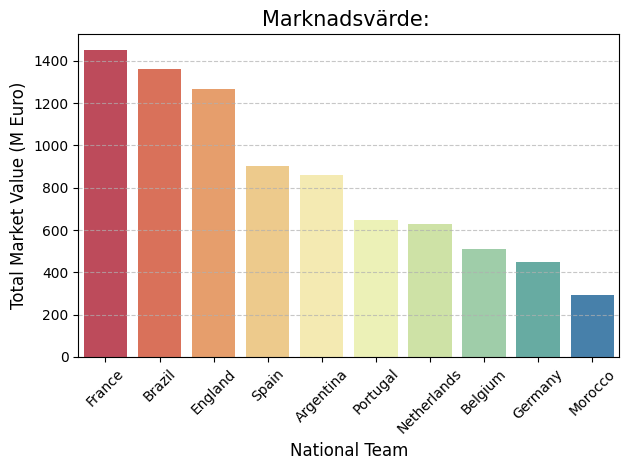

In [31]:
plt.Figure(figsize=(12, 6))

sns.barplot(
    data=top_10_expensive, 
    x="team", 
    y="total_market_value", 
    palette="Spectral", 
    hue="team", 
    legend=False
    )

plt.title(
    "Marknadsvärde: ",
    fontsize=15,
)

plt.xlabel("National Team", fontsize=12)
plt.ylabel("Total Market Value (M Euro)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

## sammanfattning

här ser vi att fraknrike, brasilien och England ligger i top. 

Det jag tycker är intressant är att morocco är på tionde plats. Det jag funderar över är om det är data felaktigheter eller om det stämmer. Att tyskland ändå ligger så långt nere kan vara intressant med. 

## 2. Ålderns ytterlighet

Vad kan vi säga utifrån truppens balans genom att se vilka tre spelare som är yngst och äldst gentemot alla landslag

In [25]:
oldest_player = df_players.nlargest(3, 'Age')[['PlayerName', 'Nationality', 'Age']]
youngest_players = df_players.nsmallest(3, 'Age')[['PlayerName', 'Nationality', 'Age']]

# merga ihopa dessa två dataseten
dataframe_age_old_young = pd.concat([oldest_player, youngest_players])

# addera en kolumn för att vi ska kunna hantera visualisering. Vi adderar färgkodning eller kategori.
dataframe_age_old_young["Kategory"] = [
    "Veteran",
    "Veteran",
    "Veteran",
    "Talang",
    "Talang",
    "Talang",
]

print("Data för åldersanalys redo:")
df_clean = dataframe_age_old_young.reset_index(drop=True)

display(df_clean)

Data för åldersanalys redo:


,PlayerName,Nationality,Age,Kategory
0,Olivier Giroud,France,37,Veteran
1,Ivan Rakitic,Croatia,36,Veteran
2,Willian,Brazil,36,Veteran
3,Alvin Ayman,England,16,Talang
4,George Ilenikhena,Nigeria,17,Talang
5,Joane Gadou,France,17,Talang


## 3. Ligornas makt

här kan man se vilken liga i vårlden som "äger" flest spelare somk spelar i landslagen

In [26]:
# här behöver vi hämta information från både players datasetet och koppla dem till transfers datasetet. Så vi mergar ihopa dem så vi kan arbeta bätrre med dem
df_players = df_players.rename(columns={"Post": "Position"})
df_merge_player_leage = pd.merge(
    df_players,
    df_market[["Name", "LeagueJoined"]],
    left_on="PlayerName",
    right_on="Name",
    how="left",
)
# print(df_merge_player_leage)


# print( "_________________________________ " )
# nu har vi mergat dessa så då behöver vi tvätta lite data från dem eftersom där finns värden som kan vara saknade.
df_merge_player_leage['LeagueJoined'] = df_merge_player_leage['LeagueJoined'].fillna('Ingen data')

# print(df_merge_player_leage)

# vi behöver inte kolumnen name från market df så vi tar bort den
df_merge_player_leage = df_merge_player_leage.drop(columns=["Name"])

# nu behöver vi räkna antalet spelare per liga
player_in_leage_count = (
    df_merge_player_leage.groupby("LeagueJoined")["PlayerName"].count().reset_index()
)


# här tänkte jag att jag kan döpa om kolumnernas namn så att det låter vettigare
player_in_leage_count.columns = ["Liga", "Antal spelare"]

top_10_leagues = player_in_leage_count.nlargest(10, "Antal spelare").reset_index(
    drop=True
)

print("De 10 ligorna med flest landslagsspelare:")
display(top_10_leagues)
#

De 10 ligorna med flest landslagsspelare:


,Liga,Antal spelare
0,Ingen data,473
1,Serie A,219
2,Premier League,201
3,Ligue 1,142
4,Bundesliga,140
5,Championship,127
6,LaLiga,125
7,Série A,105
8,Süper Lig,72
9,MLS,64


## 4. De ekonomiska jättarna

Vilka landslag har stora ekonomiska muskler efter det totala marknadsvärdet. Utgår ufrån VM 2026

In [27]:
# vi tar fram data utifrån spelarnas dataframe och grupperar dem utifrån nationalitet och marknadsvärde
team_value_data = df_players.groupby("Nationality")["MarketValue"].sum().reset_index()

# Sedan så kan vi döpa om kolumneran för att göra dem lättare att förstå
team_value_data.columns = ["Landslag", "Totalt marknadsvärde (M€)"]

# tänkte mig att använda ett stapeldiagram för att visualsiera detta och då blir det mer lättläst om vi sorterar dem utifrån z-a
team_value_data = team_value_data.sort_values(
    by="Totalt marknadsvärde (M€)", ascending=False
)

# göra en kopia av den datan ovanför för att kunna arbeta med denna men samtidigt ha kvar data i orginal skick
most_expensive_top_10_nation_teams = team_value_data.head(10).reset_index(drop=True)

# jag skapade en för de 10 som ligger i botten med
least_expensive_top_10_nations_teams = team_value_data.tail(10).reset_index(drop=True)


print("Data redo för analys av ekonomiska jättar:")
display(most_expensive_top_10_nation_teams)


print("Data redo för analys av de inte ekonomiska jättarna :")
display(least_expensive_top_10_nations_teams)

Data redo för analys av ekonomiska jättar:


,Landslag,Totalt marknadsvärde (M€)
0,France,1452.4
1,Brazil,1359.2
2,England,1268.1
3,Spain,904.5
4,Argentina,861.8
5,Italy,669.6
6,Portugal,645.4
7,Netherlands,628.4
8,Belgium,508.1
9,Germany,448.8


Data redo för analys av de inte ekonomiska jättarna :


,Landslag,Totalt marknadsvärde (M€)
0,Dominican Republic,3.000
1,Bahrain,2.500
2,Belarus,2.500
3,Iraq,2.500
4,Cyprus,2.500
5,Grenada,2.500
6,Martinique,2.500
7,Guadeloupe,1.500
8,Sierra Leone,1.000
9,Costa Rica,0.175


## 4. Pengar vs Prestation 

kan  det finnas en korrelation mellan marknadsvinster och antal vinster under det senaste åren för landslagen? 

In [33]:
# Bröjar med att skapa en total summa av alla spelares värde/nation

total_value_player_nation = df_players.groupby("Nationality")["MarketValue"].sum().reset_index()
total_value_player_nation.columns = ["National Team", "Total_MarketValue_M€"]

df_performance = df_final[["team", "total_market_value", "wins_last_4y"]].copy()

# Döpa om för snyggare tabellvisning (VG-krav)
df_performance.columns = ["National Team", "Marknadsvärde (M€)", "Vinster senaste 4 åren"]

display(df_performance.head())

,National Team,Marknadsvärde (M€),Vinster senaste 4 åren
0,Angola,35.000,19
1,Argentina,861.800,31
2,Australia,22.500,23
3,Brazil,1359.200,30
4,Costa Rica,0.175,26


## 5. Värdnationens fördel

Vilket värdland har vunnit flest matcher eller gått längs i hisitoriska VM

In [29]:
# vi behöver filtrera fram raderna från historisk data där lagen har varit värdnation
df_hosts_history = df_history[df_history["is_host"] == 1].copy()


# här kan det vara bra att kolla på totalt antal vinster samt antal vinster av hela vm.
host_success = (
    df_hosts_history.groupby("team")
    .agg(
        {
            "winner": "sum",
            "finalist": "sum",
            "semi_finalist": "sum",
            "quarter_finalist": "sum",
        }
    )
    .sort_values(by="winner", ascending=False)
)
print(host_success)

              winner  finalist  semi_finalist  quarter_finalist
team                                                           
Brazil             0         0              1                 1
Germany            0         0              1                 1
Japan              0         0              0                 0
Qatar              0         0              0                 0
Russia             0         0              0                 1
South Africa       0         0              0                 0
South Korea        0         0              1                 1


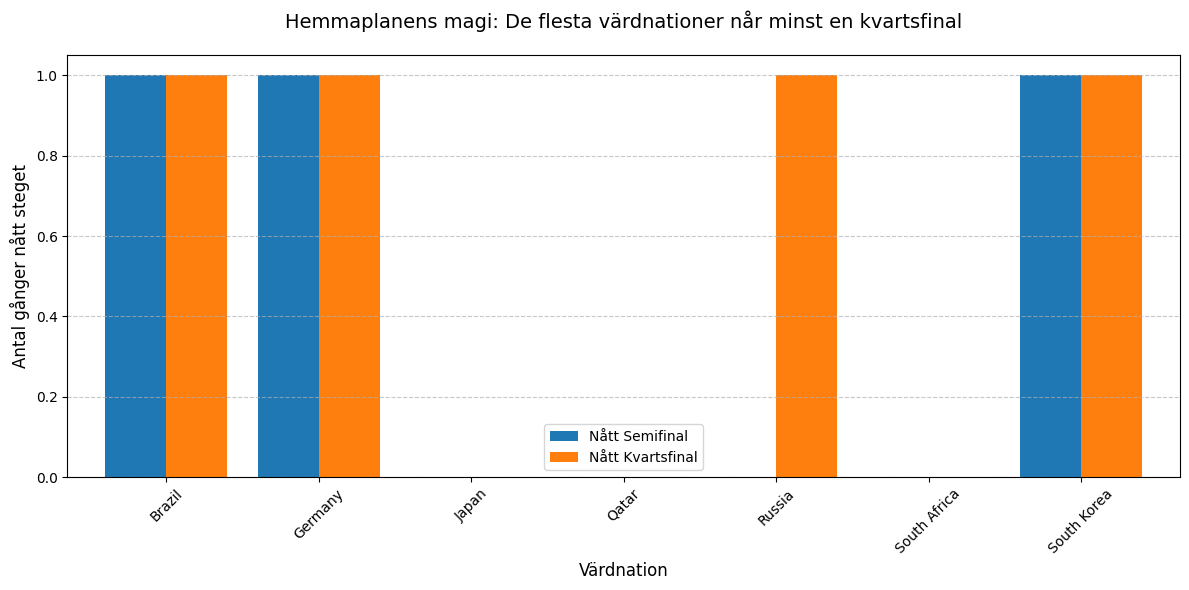

In [34]:
# Vi använder din host_success tabell
# Vi väljer att plotta de steg som faktiskt har data (Semi och Kvart i ditt fall)
plot_data = host_success[["semi_finalist", "quarter_finalist"]]

ax = plot_data.plot(kind="bar", figsize=(12, 6), width=0.8)

# VG: Påstående-titel
plt.title(
    "Hemmaplanens magi: De flesta värdnationer når minst en kvartsfinal",
    fontsize=14,
    pad=20,
)

# VG: Tydliga axlar
plt.xlabel("Värdnation", fontsize=12)
plt.ylabel("Antal gånger nått steget", fontsize=12)
plt.legend(["Nått Semifinal", "Nått Kvartsfinal"])

plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()